This notebook is used to analyze the market simulation with respect to fitting the arima models, marginal distributions and copula models. Start with analysis on the number of PCS.

Number of principal components to explain at least 90% variance: 5


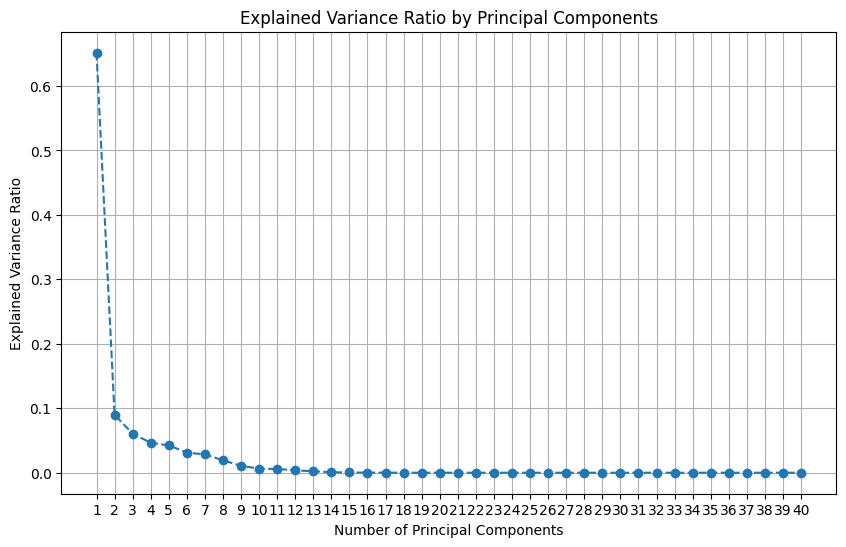

In [1]:
from marketdata import default_probabilities, discount_rates
from sim_engine import SimMarket

sim_market = SimMarket()
sim_market.transform_market_data(yield_diff=False)

sim_market.pca()
sim_market.elbow_plot()


In [2]:
sim_market = SimMarket(number_of_pcs=5)
sim_market.transform_market_data(yield_diff=False)

sim_market.pca()

0.9238063165337312
Determined degree of differencing: 1


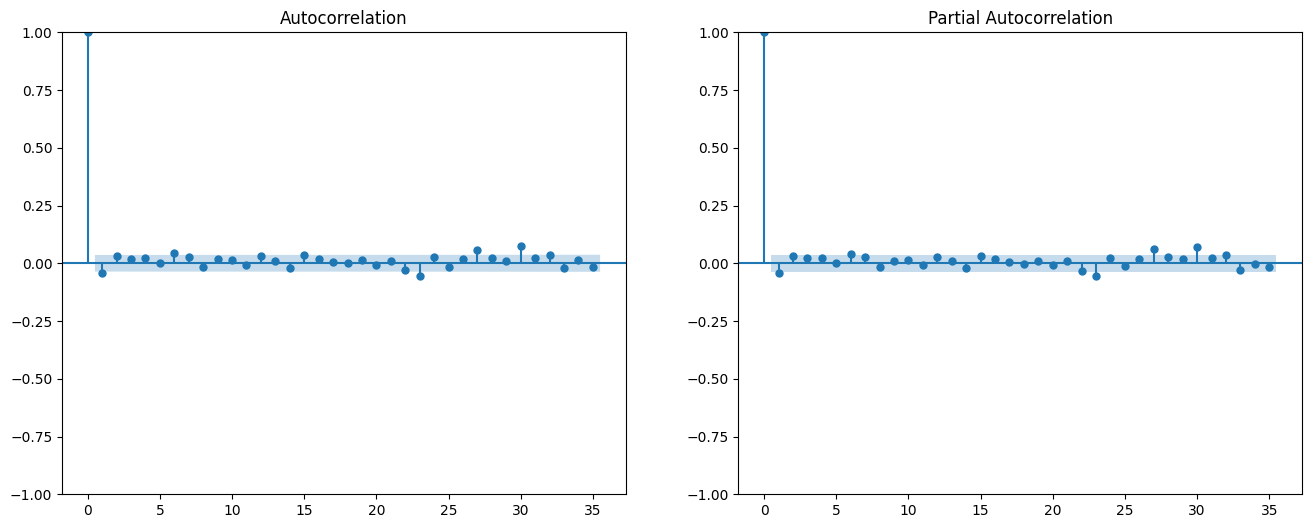

Best ARIMA order: (1, 1, 0)
Best AIC: -4123.272924692571
Best BIC: -4111.283660069707


In [11]:
sim_market.pc_tsa('PC1')

0.00010944073121634376
Determined degree of differencing: 0


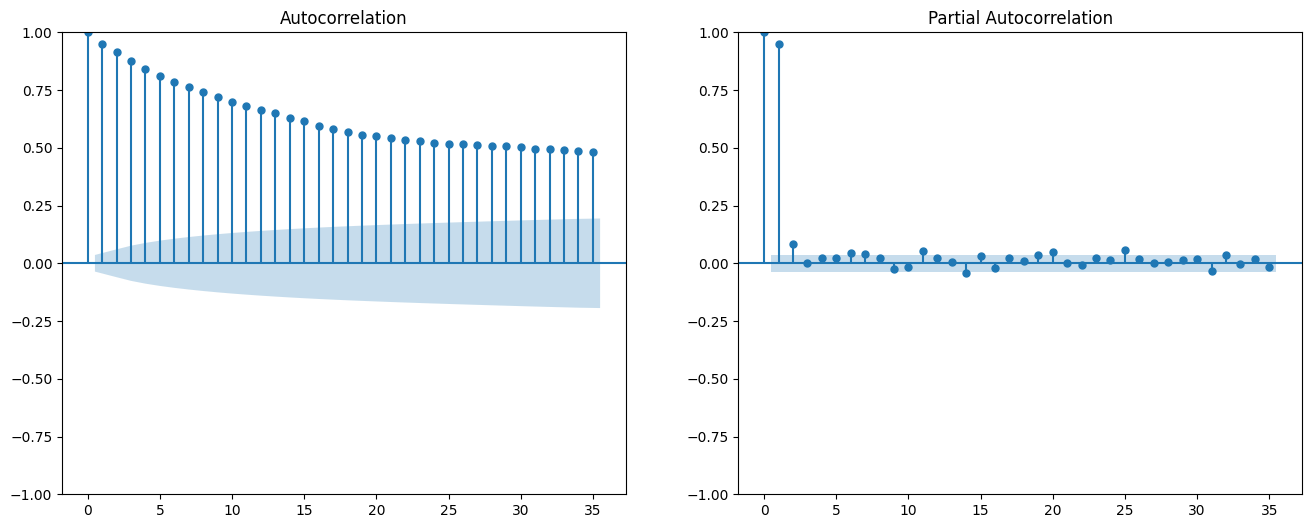

Best ARIMA order: (1, 0, 1)
Best AIC: 5218.1043226147995
Best BIC: 5242.084200705591


In [12]:
sim_market.set_arima_model('PC1', (0, 1, 0))
sim_market.pc_tsa('PC2')

3.076695013835858e-16
Determined degree of differencing: 0


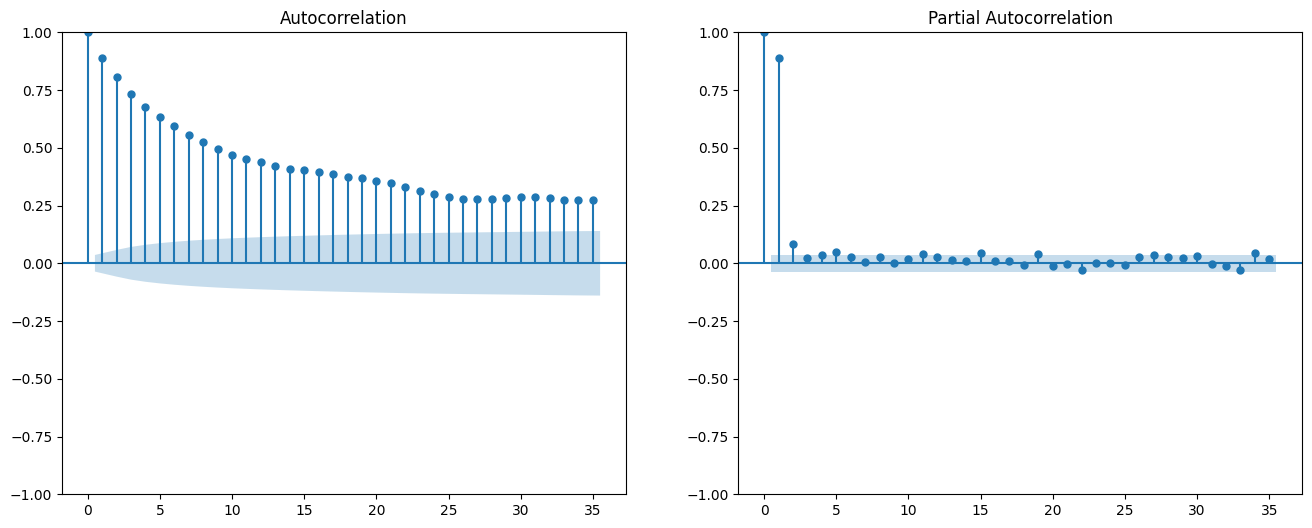

Best ARIMA order: (1, 0, 1)
Best AIC: 6437.842137323594
Best BIC: 6461.8220154143855


In [13]:
sim_market.set_arima_model('PC2', (1, 0, 0))
sim_market.pc_tsa('PC3')

1.4263610023914123e-10
Determined degree of differencing: 0


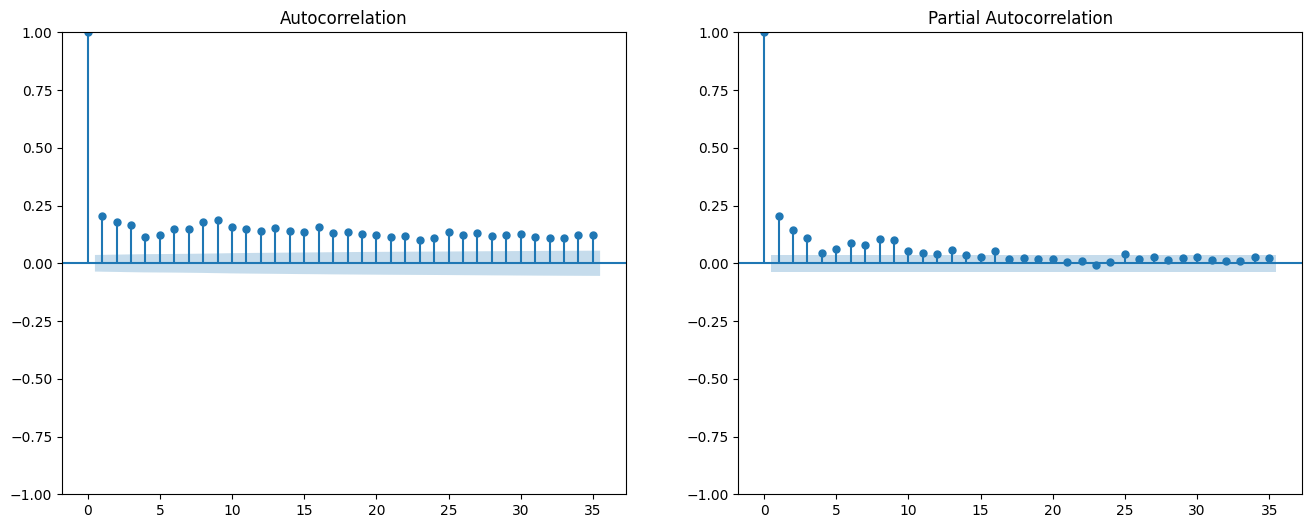

Best ARIMA order: (1, 0, 1)
Best AIC: 9881.49983187941
Best BIC: 9905.479709970201


In [15]:
sim_market.set_arima_model('PC3', (1, 0, 0))
sim_market.pc_tsa('PC4')

0.005398533875247996
Determined degree of differencing: 0


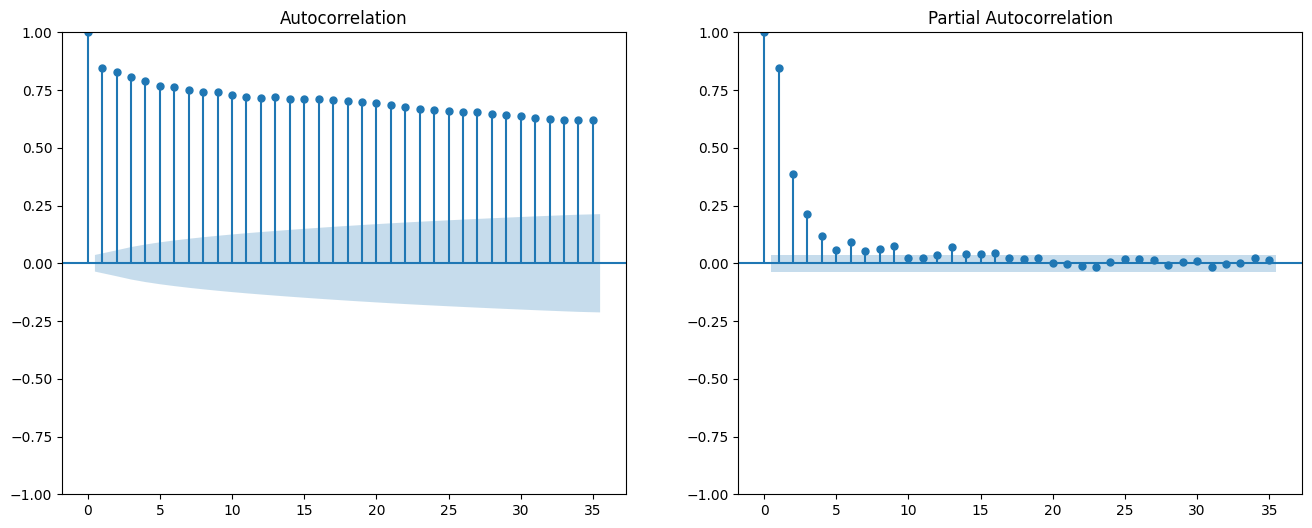

Best ARIMA order: (1, 0, 1)
Best AIC: 5517.5747574461375
Best BIC: 5541.554635536929


In [16]:
sim_market.set_arima_model('PC4', (1, 0, 0))
sim_market.pc_tsa('PC5')

In [17]:
sim_market.set_arima_model('PC5', (2, 0, 0))
# sim_market.pc_tsa('PC6')

In [ ]:
#sim_market.set_arima_model('PC6', (2, 0, 0))
#sim_market.pc_tsa('PC7')

In [ ]:
#sim_market.set_arima_model('PC7', (0, 0, 0))
#sim_market.pc_tsa('PC8')

In [ ]:
#sim_market.set_arima_model('PC8', (1, 0, 0))
#sim_market.pc_tsa('PC9')

In [ ]:
#sim_market.set_arima_model('PC9', (1, 0, 0))

In [8]:
sim_market.fit_best_distribution()
# sim_market.fit_gaussian_copula()
sim_market.fit_student_t_copula()

jf_skew_t
t
jf_skew_t
jf_skew_t
jf_skew_t


c:\Users\UGGROO\AppData\Local\anaconda3\envs\thesis\lib\site-packages\scipy\optimize\_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


               PC1          PC2          PC3          PC4          PC5
count  2966.000000  2966.000000  2966.000000  2966.000000  2966.000000
mean      0.500000     0.500000     0.500000     0.500000     0.500000
std       0.288626     0.288626     0.288626     0.288626     0.288626
min       0.000337     0.000337     0.000337     0.000337     0.000337
25%       0.250169     0.250169     0.250169     0.250169     0.250169
50%       0.500000     0.500000     0.500000     0.500000     0.500000
75%       0.749831     0.749831     0.749831     0.749831     0.749831
max       0.999663     0.999663     0.999663     0.999663     0.999663


In [ ]:
sim_market.set_arima_model('PC1', (0, 1, 0))
sim_market.set_arima_model('PC2', (1, 0, 0))
sim_market.set_arima_model('PC3', (1, 0, 0))
sim_market.set_arima_model('PC4', (1, 0, 1))
sim_market.set_arima_model('PC5', (2, 0, 1))
sim_market.fit_best_distribution()
sim_market.fit_student_t_copula()

c:\Users\UGGROO\AppData\Local\anaconda3\envs\thesis\lib\site-packages\scipy\optimize\_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\UGGROO\AppData\Local\anaconda3\envs\thesis\lib\site-packages\copulae\stats\_multivariate_t.py:116: RuntimeWarning: overflow encountered in power
  c = np.diag(1 + (x_us @ la.inv(cov) @ x_us.T) / df) ** ((dim + df) / 2)
c:\Users\UGGROO\AppData\Local\anaconda3\envs\thesis\lib\site-packages\copulae\stats\_multivariate_t.py:79: RuntimeWarning: divide by zero encountered in log
  return np.log(cls.pdf(x, mean, cov, df))


               PC1          PC2          PC3          PC4          PC5
count  2945.000000  2945.000000  2945.000000  2945.000000  2945.000000
mean      0.500000     0.500000     0.500000     0.500000     0.500000
std       0.288626     0.288626     0.288626     0.288626     0.288626
min       0.000339     0.000339     0.000339     0.000339     0.000339
25%       0.250170     0.250170     0.250170     0.250170     0.250170
50%       0.500000     0.500000     0.500000     0.500000     0.500000
75%       0.749830     0.749830     0.749830     0.749830     0.749830
max       0.999661     0.999661     0.999661     0.999661     0.999661


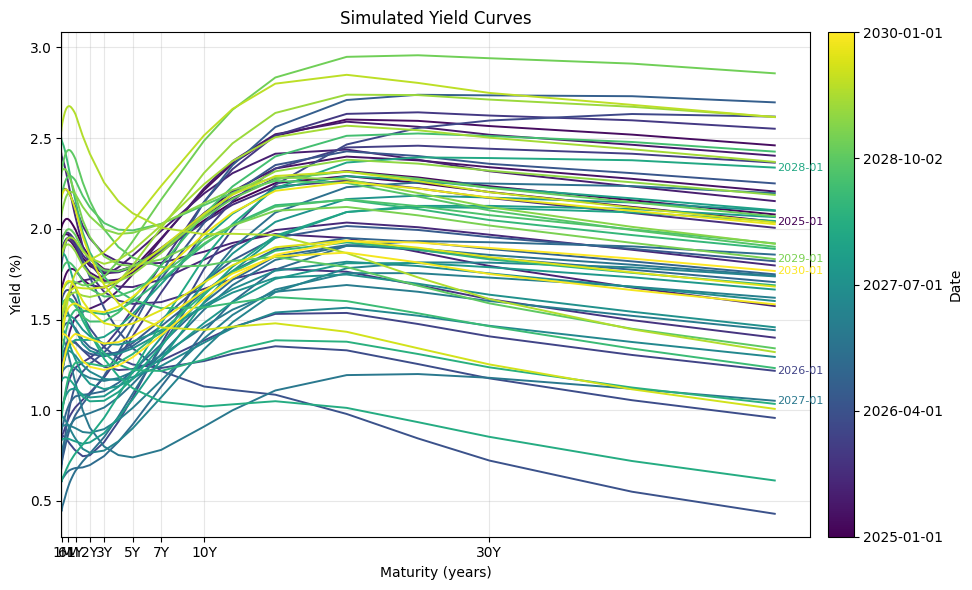

In [9]:
import matplotlib.pyplot as plt

NUM_STEPS = 52*5*7 + 2  # +2 for two leap years the coming 7 years

sim_market.simulate(num_timesteps=NUM_STEPS)
sim_market.reverse_transform(yield_diff=False)
sim_market.clean_sim_market()
sim_market.sim_yield_plot_2d()



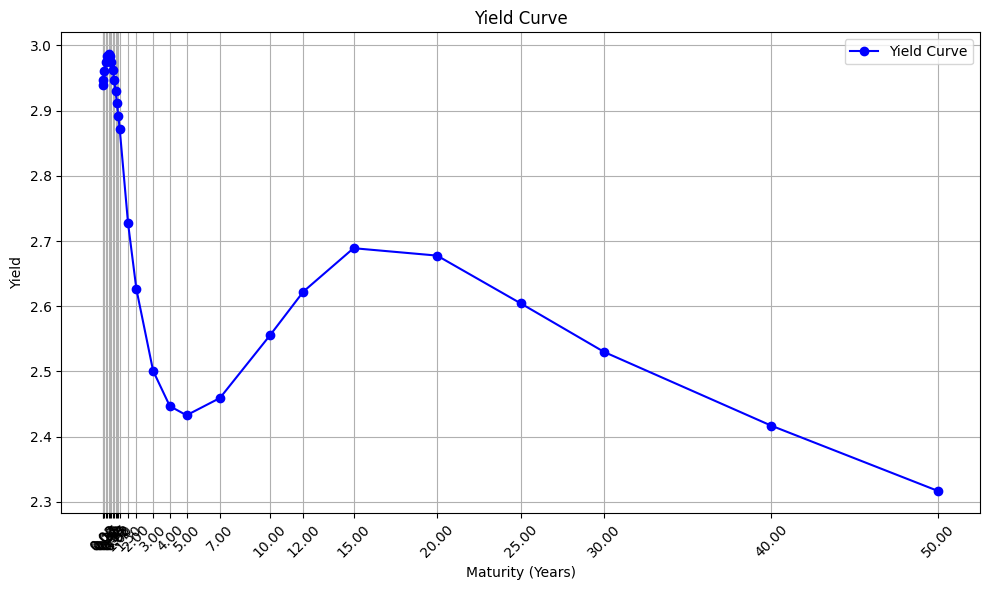

In [18]:
import numpy as np 

maturities = np.array([1/365, 7/365, 1/12, 2/12, 3/12, 4/12, 5/12, 6/12, 7/12, 8/12, 9/12, 10/12, 11/12, 1, 1.5, 2, 3, 4, 5, 7, 10, 12, 15, 20, 25, 30, 40, 50])

random_number = 1000
data = sim_market.sim_market.iloc[random_number, 9:37]
data.columns = maturities

plt.figure(figsize=(10, 6))
plt.plot(maturities, data, marker='o', linestyle='-', color='b', label='Yield Curve')

plt.title('Yield Curve')
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield')
plt.grid(True)
plt.xticks(maturities, labels=[f'{m:.2f}' for m in maturities], rotation=45)  # Custom tick labels
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show()

sim statistics:
             Values
count  1.822000e+06
mean   1.805066e-04
std    7.555890e-03
min   -1.000250e+00
25%   -3.589103e-03
50%    2.518977e-04
75%    4.053929e-03
max    9.997500e-01
skewness :    9.87640
kurtosis : 3241.22825
historic statistics:
count    2949.000000
mean        0.000186
std         0.011931
min        -0.132405
25%        -0.005272
50%         0.000530
75%         0.006159
max         0.088343
Name: Fixing, dtype: float64
skewness :   -0.80804
kurtosis :   13.43785


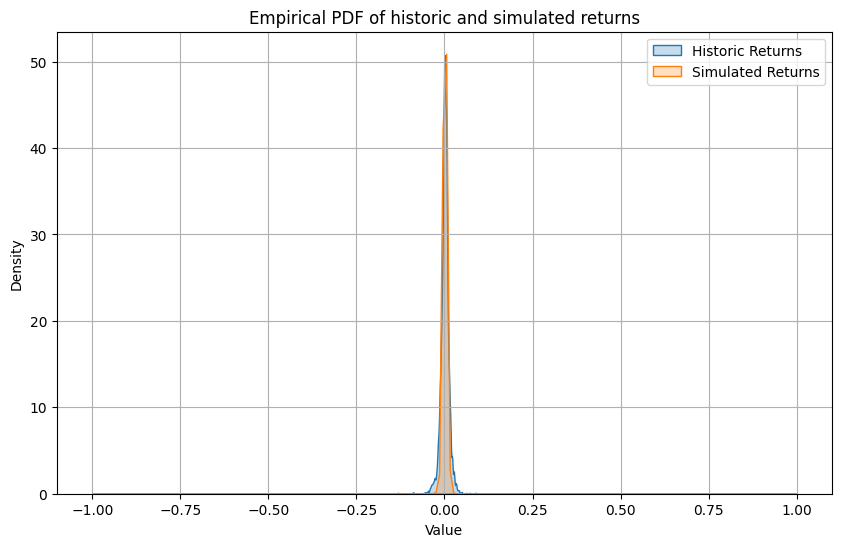

In [19]:
NUM_SIMS = 1000

sim_market.pdf_comparison(NUM_SIMS, NUM_STEPS)

[[ 1.         -0.01048541  0.00787571 ... -0.6882404  -0.69866655
  -0.70425479]
 [-0.01048541  1.         -0.98780699 ...  0.00331529  0.00888128
   0.00927001]
 [ 0.00787571 -0.98780699  1.         ... -0.00224118 -0.00825587
  -0.00872941]
 ...
 [-0.6882404   0.00331529 -0.00224118 ...  1.          0.49924346
   0.48838692]
 [-0.69866655  0.00888128 -0.00825587 ...  0.49924346  1.
   0.99560383]
 [-0.70425479  0.00927001 -0.00872941 ...  0.48838692  0.99560383
   1.        ]]


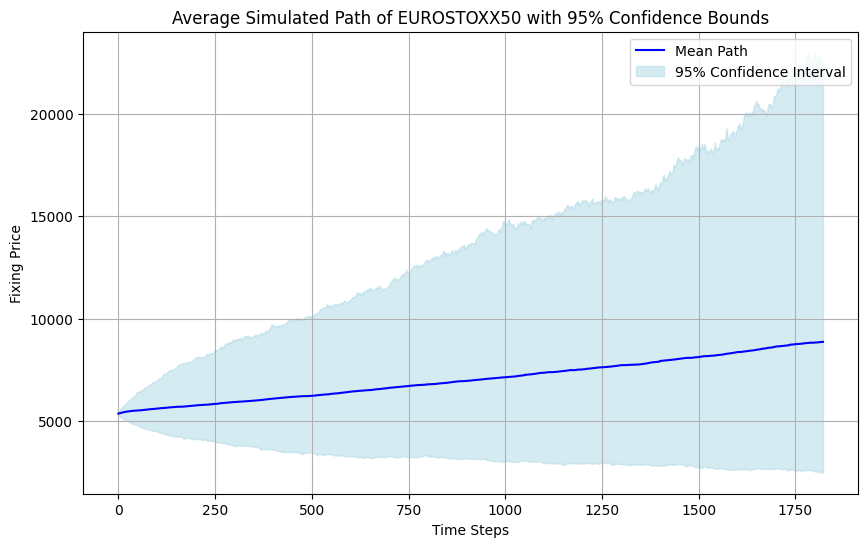

In [10]:
import numpy as np 
from scipy.stats import norm

NUM_SIMS = 1000

sim_market.complete_simulation_run(NUM_SIMS, NUM_STEPS)

data_centered = sim_market.sims - sim_market.sims.mean(axis=0, keepdims=True)
covariance_matrices = np.einsum('ijk,ilk->jlk', data_centered, data_centered) / (NUM_STEPS - 1)
std_devs = np.sqrt(np.einsum('ijk,ijk->jk', data_centered, data_centered) / (NUM_STEPS - 1))
correlation_matrices = covariance_matrices / std_devs[:, None, :] / std_devs[None, :, :]
average_correlation_matrix = correlation_matrices.mean(axis=2)
print(average_correlation_matrix)


fixing = sim_market.sims[:, 0, :]  # shape: [T, N]

# Compute empirical percentiles
lower_bound = np.percentile(fixing, 2.5, axis=1)
upper_bound = np.percentile(fixing, 97.5, axis=1)

# Compute mean path (optional, just for visualization)
mean_path = np.mean(fixing, axis=1)
median_path = np.median(fixing, axis=1)

time_steps = np.arange(fixing.shape[0])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(time_steps, mean_path, label='Mean Path', color='blue')
#plt.plot(time_steps, median_path, label='Median Path', color='red')
plt.fill_between(time_steps, lower_bound, upper_bound, 
                 color='lightblue', alpha=0.5, label='95% Confidence Interval')

plt.title('Average Simulated Path of EUROSTOXX50 with 95% Confidence Bounds')
plt.xlabel('Time Steps')
plt.ylabel('Fixing Price')
plt.legend()
plt.grid(True)
plt.show()
